In [100]:
import zipfile
import os
import pathlib
import laspy
import numpy as np
import pandas as pd

base_path = pathlib.Path("~/").expanduser()
data_path = base_path / "data"
lidar_path = base_path / "data" / "raw" / "lidar-vancouver"
temp_path = base_path / "temp"

In [101]:
# Load the index file

index_df = pd.read_csv(lidar_path / "index.csv", sep=";")
index_df

,NAME,LiDAR_URL,Geom,geo_point_2d
0,481000_5456000,https://webtransfer.vancouver.ca/opendata/2022...,"{""coordinates"": [[[-123.26111023690703, 49.256...","49.260984869792686, -123.2542620904058"
1,482000_5458000,https://webtransfer.vancouver.ca/opendata/2022...,"{""coordinates"": [[[-123.24745768052215, 49.274...","49.279004526408976, -123.2406057971606"
2,483000_5453000,https://webtransfer.vancouver.ca/opendata/2022...,"{""coordinates"": [[[-123.23349793304287, 49.229...","49.234056616091735, -123.22665097915451"
3,485000_5452000,https://webtransfer.vancouver.ca/opendata/2022...,"{""coordinates"": [[[-123.20599039173608, 49.220...","49.225112047464414, -123.19914216184115"
4,486000_5451000,https://webtransfer.vancouver.ca/opendata/2022...,"{""coordinates"": [[[-123.19222289823045, 49.211...","49.216139683399994, -123.18537465062653"
...,...,...,...,...
176,483000_5457000,https://webtransfer.vancouver.ca/opendata/2022...,"{""coordinates"": [[[-123.23366766847829, 49.265...","49.270037221137514, -123.22681576359882"
177,493000_5452000,https://webtransfer.vancouver.ca/opendata/2022...,"{""coordinates"": [[[-123.09612910454722, 49.220...","49.22524920621635, -123.08927085043152"
178,494000_5457000,https://webtransfer.vancouver.ca/opendata/2022...,"{""coordinates"": [[[-123.08247125711047, 49.265...","49.27023510667984, -123.07560553107605"
179,496000_5451000,https://webtransfer.vancouver.ca/opendata/2022...,"{""coordinates"": [[[-123.05492097703745, 49.211...","49.216278431381795, -123.048060217755"


In [102]:
from pyproj import Transformer

def load_lidar(name):
    las_file = temp_path / f"{name}.las"
    try:
        # The uncompressed file does not need to live long
        with zipfile.ZipFile(lidar_path / f"{name}.zip", 'r') as zip_ref:
            zip_ref.extract(las_file.name, temp_path)

        las = laspy.read(las_file)
        x, y = np.asarray(las.x), np.asarray(las.y)
        # Points are in a weird system (UTM); lat/lon is computed per grid cell in re_grid
        meta = {
            "crs": las.header.parse_crs(),
            "x_min": x.min(), "x_max": x.max(),
            "y_min": y.min(), "y_max": y.max(),
        }
        df = pd.DataFrame({
            "alt": np.asarray(las.z),  # meters
            "rel_x": (x - meta["x_min"]) / (meta["x_max"] - meta["x_min"]),
            "rel_y": (y - meta["y_min"]) / (meta["y_max"] - meta["y_min"]),
        })
        return df, meta
    finally:
        las_file.unlink(missing_ok=True)

las_df, las_meta = load_lidar(index_df["NAME"][0])

In [103]:
def re_grid(df, resolution, meta):
    df["grid_x"] = (np.round(df["rel_x"] * (resolution - 1))).astype(int)
    df["grid_y"] = (np.round(df["rel_y"] * (resolution - 1))).astype(int)
    grid = df.groupby(["grid_x", "grid_y"])["alt"].max()
    # Cells with no points are dropped by groupby
    # Backfilling so the df contains exactly resolution^2 points
    full_index = pd.MultiIndex.from_product(
        [range(resolution), range(resolution)], names=["grid_x", "grid_y"]
    )
    out = grid.reindex(full_index).reset_index()
    out["missing"] = out["alt"].isna()
    out["alt"] = out["alt"].fillna(0)

    # Cell centers back in UTM, then to lat/lon (also covers the backfilled cells)
    x = meta["x_min"] + out["grid_x"] / (resolution - 1) * (meta["x_max"] - meta["x_min"])
    y = meta["y_min"] + out["grid_y"] / (resolution - 1) * (meta["y_max"] - meta["y_min"])
    transformer = Transformer.from_crs(meta["crs"], "EPSG:4326", always_xy=True)
    out["lon"], out["lat"] = transformer.transform(x.to_numpy(), y.to_numpy())
    return out

resolution = 2000
down_df = re_grid(las_df, resolution, las_meta)
down_df

,grid_x,grid_y,alt,missing,lon,lat
0,0,0,-0.991,False,-123.261110,49.256472
1,0,1,-1.031,False,-123.261110,49.256477
2,0,2,-1.089,False,-123.261110,49.256481
3,0,3,-1.105,False,-123.261110,49.256486
4,0,4,-1.177,False,-123.261110,49.256490
...,...,...,...,...,...,...
3999995,1999,1995,89.539,False,-123.247413,49.265479
3999996,1999,1996,89.252,False,-123.247413,49.265484
3999997,1999,1997,89.031,False,-123.247413,49.265488
3999998,1999,1998,88.781,False,-123.247413,49.265493


[[  1   1   1 ... 121 120 119]
 [  1   1   1 ... 122 119 119]
 [  1   1   1 ... 121 121 119]
 ...
 [205 206 207 ... 150 149 149]
 [207 206 204 ... 150 149 149]
 [204 205 201 ... 150 150   3]]


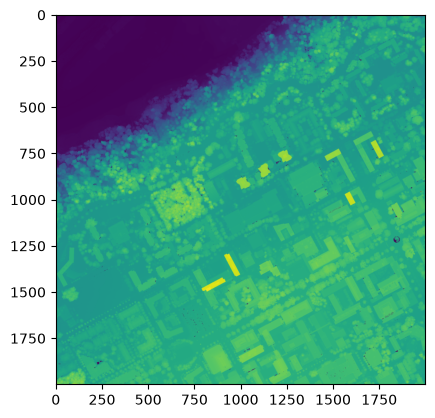

In [104]:
import matplotlib.pyplot as plt

img = np.array(((down_df["alt"] - down_df["alt"].min()) / (down_df["alt"].max() - down_df["alt"].min()) * 255).astype("uint8")).reshape((resolution, resolution))

print(img)
plt.imshow(img)

In [105]:
import multiprocessing
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.auto import tqdm

export_all = True
export_path = data_path / "lidar-vancouver-altitude"
# Each worker peaks at several GB of RAM for a full tile, so keep this modest
max_workers = 4

def export_tile(name):
    out_file = export_path / f"{name}.parquet"
    if out_file.exists():
        return name, "skipped"
    df, meta = load_lidar(name)
    down = re_grid(df, resolution, meta)
    # Write to a temp file first so an interrupted run never leaves a partial parquet behind
    tmp_file = out_file.with_suffix(".parquet.tmp")
    down[["lat", "lon", "alt"]].to_parquet(tmp_file, index=False)
    tmp_file.replace(out_file)
    return name, "exported"

if export_all:
    export_path.mkdir(parents=True, exist_ok=True)
    temp_path.mkdir(parents=True, exist_ok=True)
    failed = {}
    # fork so workers can see the functions defined in this notebook
    with ProcessPoolExecutor(max_workers, mp_context=multiprocessing.get_context("fork")) as pool:
        futures = {pool.submit(export_tile, name): name for name in index_df["NAME"]}
        for future in tqdm(as_completed(futures), total=len(futures), desc="Exporting tiles"):
            try:
                future.result()
            except Exception as e:
                failed[futures[future]] = repr(e)
    print(f"Done: {len(futures) - len(failed)} ok, {len(failed)} failed")
    for name, err in failed.items():
        print(f"  {name}: {err}")

Exporting tiles:   0%|          | 0/181 [00:00<?, ?it/s]

Done: 181 ok, 0 failed
